<a href="https://colab.research.google.com/github/rosagtr95/Data-Science-112-Final-Project/blob/main/DataSci_112_Winter26_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Manufacturing Fear: A Computational Analysis of Horror Games and News Media**

Gabrielle Rosado & Sue Zhang

Yay welcome to the Colab! Throughout this project we explore the relationships between horror video games and current news media (specifically relating to crime or disaster). Through TF-IDFs, PCA Maps, NRC Lexicons, WordClouds, machine learning and more, we consider the variety of language choices between fiction and non-fiction  media and analyze how this may affect how we interpret the information we recieve in both contexts.


# Horror Game Dictionary

This is the dictionary of games we will be using for this research, centered around the highest grossing horror games in the U.S. right now.
-Note: Game scripts are pretty difficult to find so this specialized horror game script was manually collected them and constructed a corpus based on available (and accurate) transcriptions with open api for web scraping. We were able to find about 20 scripts which we broke down into smaller segments that would give us a similar data set size to the news articles.


In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import re


# Horror Game Scripts

games = {
    "RE2_remake": "https://game-scripts-wiki.blogspot.com/2019/07/resident-evil-2-2019-full-transcript.html",
    "RE3_remake": "https://game-scripts-wiki.blogspot.com/2020/04/resident-evil-3-2020-full-transcript.html",
    "RE4_remake": "https://game-scripts-wiki.blogspot.com/2023/05/resident-evil-4-remake-full-transcript.html",
    "RE6": "https://game-scripts-wiki.blogspot.com/2021/06/resident-evil-6-transcript.html",
    "RE7": "https://game-scripts-wiki.blogspot.com/2018/12/resident-evil-7-full-transcript.html",
    "RE8": "https://game-scripts-wiki.blogspot.com/2021/05/resident-evil-8-village-full-transcript.html",
    "Silent Hill": "https://gamefaqs.gamespot.com/ps/198641-silent-hill/faqs/27131",
    "Silent Hill 2": "https://gamefaqs.gamespot.com/ps2/437029-silent-hill-2/faqs/18290",
    "Silent Hill 3": "https://gamefaqs.gamespot.com/ps2/561292-silent-hill-3/faqs/23772",
    "Silent Hill 4": "https://gamefaqs.gamespot.com/ps2/919554-silent-hill-4-the-room/faqs/31470",
    "Fatal Frame": "https://game-scripts-wiki.blogspot.com/2019/03/fatal-frame-full-transcript.html",
    "The Last of Us Part I": "https://gamefaqs.gamespot.com/ps3/652686-the-last-of-us/faqs/68485",
    "The Last of Us Part II": "https://game-scripts-wiki.blogspot.com/2020/10/the-last-of-us-part-ii-full-transcript.html",
    "BioShock I": "https://game-scripts-wiki.blogspot.com/2022/01/bioshock-full-transcript.html",
    "BioShock II": "https://game-scripts-wiki.blogspot.com/2018/07/bioshock-2-full-transcript.html",
    "FNAF": "https://game-scripts-wiki.blogspot.com/2022/03/five-nights-at-freddys-security-breach.html",
    "Dead Space I": "https://game-scripts-wiki.blogspot.com/2021/07/dead-space-full-transcript.html",
    "Dead Space II": "https://game-scripts-wiki.blogspot.com/2022/08/dead-space-2-full-transcript.html",
    "Doom": "https://game-scripts-wiki.blogspot.com/2025/06/doom-dark-ages-full-transcript.html",
    "MediEvil": "https://game-scripts-wiki.blogspot.com/2022/01/medievil-1998-full-transcript.html",
    "At Dead of Night": "https://www.dawnborn.com/game-transcripts/at-dead-of-night-game-transcript/"
}

# Horror Game Script Web Scraping

Each script is scraped off the appropriate website (with a 2 second delay period to not overload the server or cause harm). The scraped text is then split into smaller "chunks" of about 50 words to make our graph data more precise since we do not have thousands of whole game documents to analyize. This also works better for using NRC for emotion scoring later on.
(Horror game segments: 5673 means that we now have 5673 individual text lines to process and compare with news sources)


In [ ]:


def chunk_text(text, chunk_size=50):
    """Split text into chunks of roughly chunk_size words."""
    words = text.split()
    return [" ".join(words[i:i+chunk_size]) for i in range(0, len(words), chunk_size)]

# Scrape game scripts
game_segments = []

for game, url in games.items():
    print("Scraping:", game)
    r = requests.get(url)
    soup = BeautifulSoup(r.text, "html.parser")

    text = ""

    # Blogspot transcripts
    article = soup.find("div", class_="post-body")
    if article:
        text = article.get_text(separator=" ", strip=True)

    # GameFAQs transcripts
    if "gamefaqs" in url:
        faq = soup.find("pre")
        if faq:
            text = faq.get_text(separator=" ", strip=True)

    if text == "":
        text = soup.get_text(separator=" ", strip=True)

    # Split into 50-word chunks
    chunks = chunk_text(text, chunk_size=50)
    for chunk in chunks:
        game_segments.append({
            "media_type": "horror_game",
            "source": game,
            "text": chunk
        })

    time.sleep(2)  # ethical delay

df_game_segments = pd.DataFrame(game_segments)
print("Horror game segments:", len(df_game_segments))



Scraping: RE2_remake
Scraping: RE3_remake
Scraping: RE4_remake
Scraping: RE6
Scraping: RE7
Scraping: RE8
Scraping: Silent Hill
Scraping: Silent Hill 2
Scraping: Silent Hill 3
Scraping: Silent Hill 4
Scraping: Fatal Frame
Scraping: The Last of Us Part I
Scraping: The Last of Us Part II
Scraping: BioShock I
Scraping: BioShock II
Scraping: FNAF
Scraping: Dead Space I
Scraping: Dead Space II
Scraping: Doom
Scraping: MediEvil
Scraping: At Dead of Night
Horror game segments: 5673


Here are the segments we get from scraping and chunking:


In [ ]:
df_game_segments

,media_type,source,text
0,horror_game,RE2_remake,Note: I highly recommend you to read the origi...
1,horror_game,RE2_remake,"with my own eyes. Anchor: Oh, I believe you, b..."
2,horror_game,RE2_remake,"So I, I figured she was drunk. Anchor: Whoa, w..."
3,horror_game,RE2_remake,"her. You had to see her eyes, her nose… Her wh..."
4,horror_game,RE2_remake,"since of that night. Anchor: Alright, calm dow..."
...,...,...,...
5668,horror_game,At Dead of Night,"innovative use of live-action performances, an..."
5669,horror_game,At Dead of Night,"clues to unlock each ghost’s story, gradually ..."
5670,horror_game,At Dead of Night,studio: 📄 Contradiction: Spot the Liar! Our Re...
5671,horror_game,At Dead of Night,Chapter 6 – Hugo Punch All Clues Dialogues All...


# News API Webscraping

We used News API with an API key that allowed us to go through many pages of top headlines, scrap them, then chunck them into smaller segments that will be more compatable with NRC lexicon and also give us more data to work with if we are looking at each individual line. I scrapped through pages of the NewsAPI with delays.

In [ ]:

# NewsAPI Top Headlines

api_key = "099177eddce541729bb6dfa03a2fea72"
sources = "cnn,fox-news,abc-news,cbs-news,nbc-news,the-new-york-times,usa-today,the-washington-post"

news_segments = []

for page in range(1, 31):  # 30 pages x 200 articles = ~6000 articles
    url = (
      "https://newsapi.org/v2/everything?"
      "q=crime OR disaster OR attack OR shooting OR terror OR scared OR war OR danger"
      f"&sources={sources}"
      "&language=en"
      "&pageSize=100"
      f"&apiKey={api_key}"
)

    response = requests.get(url).json()

    if "articles" in response:
        for article in response["articles"]:
            text = (article.get("title") or "") + " " + (article.get("description") or "") + " " + (article.get("content") or "")
            chunks = chunk_text(text, chunk_size=50)
            for chunk in chunks:
                news_segments.append({
                    "media_type": "news",
                    "source": article["source"]["name"],
                    "text": chunk
                })

    time.sleep(2)  # ethical delay

df_news_segments = pd.DataFrame(news_segments)
print("News segments:", len(df_news_segments))



News segments: 5820


# Combining Databases

We simply used pd.concat to combine both databases, putting one on top of the other for simple comparison methods since they have the same columns and information types. Together, it gave us 11493 text segments to analyze.

In [ ]:

# 3. Combine Game + News

df_all = pd.concat([df_game_segments, df_news_segments], ignore_index=True)

# Clean text for NRC
df_all["clean_text"] = df_all["text"].str.lower()
df_all["clean_text"] = df_all["clean_text"].apply(lambda x: re.sub(r"[^a-z\s]", "", x))

print("Total Segments (games + news):", len(df_all))
print(df_all.head())

Total Segments (games + news): 11493
    media_type      source                                               text  \
0  horror_game  RE2_remake  Note: I highly recommend you to read the origi...   
1  horror_game  RE2_remake  with my own eyes. Anchor: Oh, I believe you, b...   
2  horror_game  RE2_remake  So I, I figured she was drunk. Anchor: Whoa, w...   
3  horror_game  RE2_remake  her. You had to see her eyes, her nose… Her wh...   
4  horror_game  RE2_remake  since of that night. Anchor: Alright, calm dow...   

                                          clean_text  
0  note i highly recommend you to read the origin...  
1  with my own eyes anchor oh i believe you buddy...  
2  so i i figured she was drunk anchor whoa whoa ...  
3  her you had to see her eyes her nose her whole...  
4  since of that night anchor alright calm down b...  


# Tfidf Vectorizer: Extracting and Correcting 'Fear Words'

Our first idea was to use the TF-IDF vectorizor to find the 'fear words' in all the documents. All though we will be using the NRC lexicon later on, we wanted to understand what results would yeild from comparing the two types of documents. We also ended up constructing out own dictionary to use to make sure that we were actually capturing some fear langauge and less filler words. This allowed us to make a fear_score that we will use later on in our visualizations.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Only use horror game segments
game_texts = df_all[df_all["media_type"]=="horror_game"]["clean_text"]

vectorizer = TfidfVectorizer(stop_words='english', max_features=500)  # top 500 words
X = vectorizer.fit_transform(game_texts)

# Get the top words
tfidf_scores = dict(zip(vectorizer.get_feature_names_out(), X.toarray().sum(axis=0)))

# Sort by TF-IDF
fear_vocab = sorted(tfidf_scores, key=tfidf_scores.get, reverse=True)[:100]  # top 100 fear-related words

print("Sample fear words:", fear_vocab[:20])

Sample fear words: ['ellie', 'leon', 'isaac', 'ethan', 'abby', 'im', 'just', 'dina', 'dont', 'like', 'way', 'right', 'know', 'finds', 'chris', 'got', 'come', 'radio', 'man', 'youre']


^ Our first issue was that there were too many names from main characters in our video games that had nothing to do with our main idea. To correct this, we manually removed the main character names from the Tfidf vectorizor and other filler words that created more noise in the data.


In [ ]:
#  character names from games
character_names = [
    'ellie','leon','isaac','ethan','abby','dina','chris','jake','sherry','ada',
    'jill','claire','alan','pierre','rebecca','marcus','franklin'
]

# Common stopwords / filler words
stop_words = [
    'im','just','dont','like','way','right','know','got','come','youre','i','he','she',
    'they','we','it','was','had','would','could','also','thats','thats','the','a','an'
]

In [ ]:

vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
X = vectorizer.fit_transform(game_texts)

# All words sorted by TF-IDF score
tfidf_scores = dict(zip(vectorizer.get_feature_names_out(), X.toarray().sum(axis=0)))
sorted_words = sorted(tfidf_scores, key=tfidf_scores.get, reverse=True)


fear_vocab = [w for w in sorted_words if w not in character_names + stop_words]

manual_fear_words = [
    "scream","blood","kill","death","dark","shadow","fear","terror","panic",
    "monster","haunt","scare","fight","run","escape","die","attack","danger",
    "shock","trap","creepy","horror","gun","knife","scream","screaming"
]

fear_vocab.extend(manual_fear_words)

fear_vocab = list(set(fear_vocab))  # remove duplicates

def fear_score(text, fear_vocab):
    words = text.split()
    return sum(1 for w in words if w in fear_vocab)

df_all['fear_score'] = df_all['clean_text'].apply(lambda x: fear_score(x, fear_vocab))

# 1. Count the total words in each document
df_all['word_count'] = df_all['clean_text'].apply(lambda x: len(str(x).split()))

# 2. Calculate the percentage (Fear Words / Total Words * 100)
# We add 1 to the denominator just in case there's an empty text to avoid a 'division by zero' error
df_all['fear_percentage'] = (df_all['fear_score'] / (df_all['word_count'] + 1)) * 100
# Check average fear scores
print(df_all.groupby('media_type')['fear_score'].mean())

media_type
horror_game    13.952230
news            4.654639
Name: fear_score, dtype: float64


We see that based on our TF-IDF and manual words, horror games initially has a much higher fear_score, because we defined fear based off of horror game language. This score represents the average percentage of words in the overall text that are categorized as a fear word.


# Individual Fear Scores for News Articles and Games

In [ ]:
df_all[df_all['media_type']=="news"].sort_values('fear_score', ascending=False)[['source','text','fear_score']]

,source,text,fear_score
9045,CBS News,Officer took ambulance sent for man dying from...,22
6329,CBS News,Officer took ambulance sent for man dying from...,22
10597,CBS News,Officer took ambulance sent for man dying from...,22
8463,CBS News,Officer took ambulance sent for man dying from...,22
9821,CBS News,Officer took ambulance sent for man dying from...,22
...,...,...,...
5706,CBS News,Matt Gutman reports. Copyright ©2026 CBS Inter...,0
5708,USA Today,the faithful to the injustices and anti-democr...,0
11454,CBS News,"including brain trauma, shrapnel wounds and bu...",0
8049,CBS News,had expressed frustration with the progress of...,0


In [ ]:
df_all[df_all['media_type']=="horror_game"].sort_values('fear_score', ascending=False)

,media_type,source,text,clean_text,fear_score,word_count,fear_percentage
4401,horror_game,FNAF,Map Bot opens the doors.] Map Bot: Free map. F...,map bot opens the doors map bot free map free ...,30,50,58.823529
3247,horror_game,The Last of Us Part II,Isaac is? Woman: He was here a few minutes ago...,isaac is woman he was here a few minutes ago a...,29,50,56.862745
3467,horror_game,The Last of Us Part II,Shut up. (killing) Don’t try anything. (killin...,shut up killing dont try anything killing shut...,28,50,54.901961
527,horror_game,RE3_remake,Now fuck off. And don't say a word to anyone. ...,now fuck off and dont say a word to anyone car...,27,50,52.941176
3242,horror_game,The Last of Us Part II,be out. Manny: She’ll be okay. She’ll be okay....,be out manny shell be okay shell be okay wlf s...,27,50,52.941176
...,...,...,...,...,...,...,...
4242,horror_game,BioShock II,"a formula, waiting on us to solve for X.’ Inte...",a formula waiting on us to solve for x intelli...,1,50,1.960784
1593,horror_game,RE6,exit of the diner.],exit of the diner,1,4,20.000000
5672,horror_game,At Dead of Night,Dawnborn Contact AO3 FanFiction.net Neve | Pow...,dawnborn contact ao fanfictionnet neve powere...,1,19,5.000000
5380,horror_game,Doom,of unfathomable dread where reality warps and ...,of unfathomable dread where reality warps and ...,0,50,0.000000


# (Visualization 1) Fear Score Distributions (Figure 1)

We now move on to making the first visualization which shows the comparison between both distributions of fear scores.

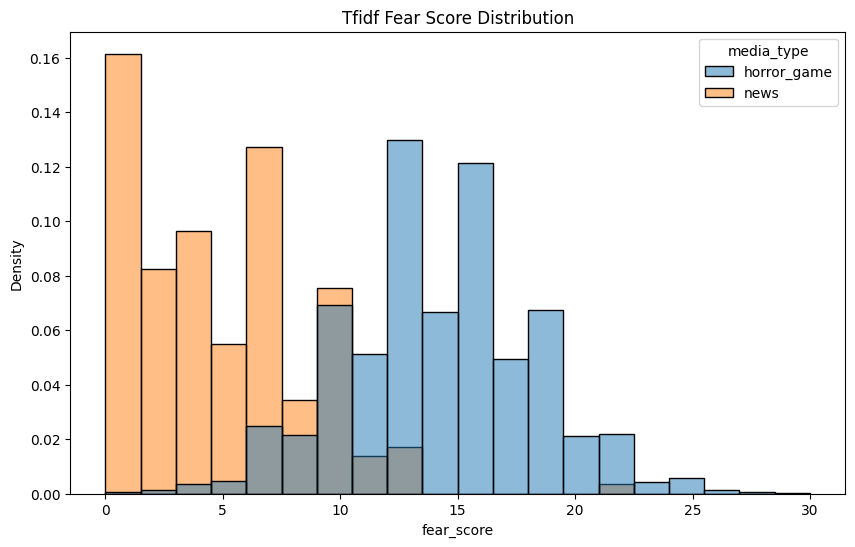

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(df_all, x='fear_score', hue='media_type',
             bins=20, stat="density", common_norm=False, alpha=0.5)
plt.title("Tfidf Fear Score Distribution")
plt.show()

In [ ]:
df_all

,media_type,source,text,clean_text,fear_score,word_count,fear_percentage
0,horror_game,RE2_remake,Note: I highly recommend you to read the origi...,note i highly recommend you to read the origin...,9,50,17.647059
1,horror_game,RE2_remake,"with my own eyes. Anchor: Oh, I believe you, b...",with my own eyes anchor oh i believe you buddy...,15,49,30.000000
2,horror_game,RE2_remake,"So I, I figured she was drunk. Anchor: Whoa, w...",so i i figured she was drunk anchor whoa whoa ...,15,50,29.411765
3,horror_game,RE2_remake,"her. You had to see her eyes, her nose… Her wh...",her you had to see her eyes her nose her whole...,13,49,26.000000
4,horror_game,RE2_remake,"since of that night. Anchor: Alright, calm dow...",since of that night anchor alright calm down b...,12,50,23.529412
...,...,...,...,...,...,...,...
11488,news,NBC News,"speech this week was that the ""golden age of A...",speech this week was that the golden age of am...,1,14,6.666667
11489,news,CBS News,"Trump tells CBS News ""the war is very complete...",trump tells cbs news the war is very complete ...,13,50,25.490196
11490,news,CBS News,"with Iran could almost be over. ""I think the w...",with iran could almost be over i think the war...,5,20,23.809524
11491,news,CBS News,"Watch Live: Hegseth, Caine give Iran war updat...",watch live hegseth caine give iran war update ...,5,50,9.803922


# (Visualization 2) PCA

The principal component analysis map finds similarity through clustering data points. Using PCA, we were able to find the 3 news outlets that use language closest to the horror game script data. The clustering is done by finding 2 main themes or trends in the data set that the PCA is able to "flatten" the data on and start to make connections, or clusters, that we can analysize. We see that the news articles are more spread out than the video games because of content variations, but their density is actually very close to video games.



In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import MaxAbsScaler

# 1. Vectorize with noise reduction (min_df/max_df)
vectorizer = TfidfVectorizer(max_features=500, stop_words='english', min_df=2, max_df=0.9)
X_tfidf = vectorizer.fit_transform(df_all['clean_text'])

# 2. Scale the data (Crucial for better spreading in PCA)
scaler = MaxAbsScaler()
X_scaled = scaler.fit_transform(X_tfidf)

# 3. Run PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled.toarray())

# 4. Assign back to dataframe
df_all['pca_x'] = X_pca[:, 0]
df_all['pca_y'] = X_pca[:, 1]


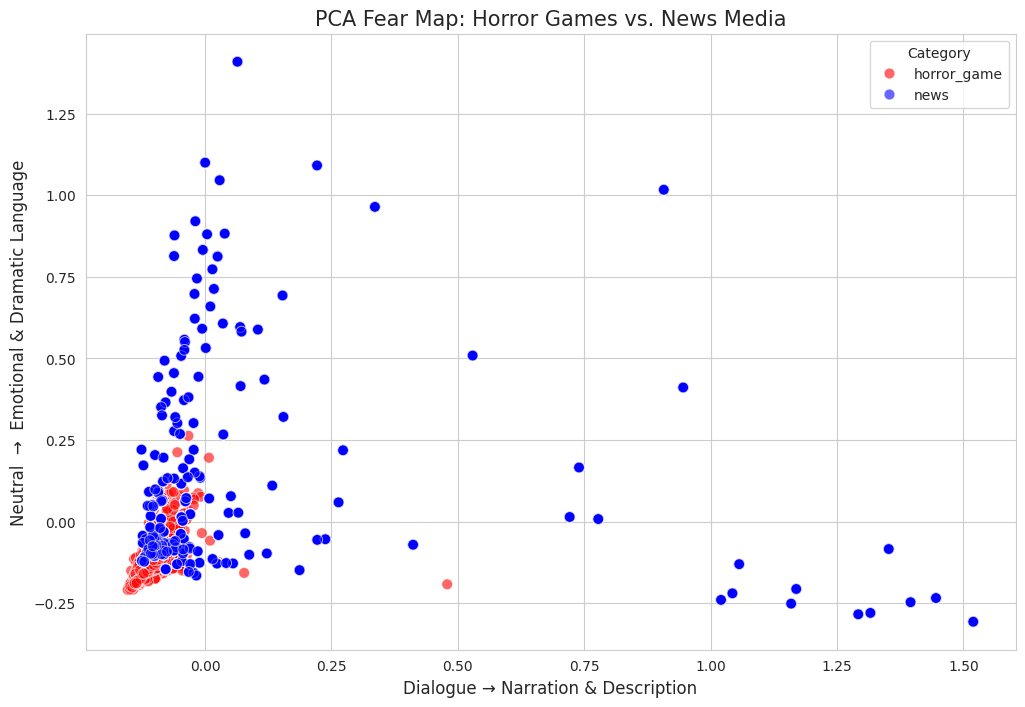

In [ ]:

# Set the style
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Create the scatter plot
# We color by 'media_type' so Horror and News are distinct
sns.scatterplot(
    x='pca_x',
    y='pca_y',
    hue='media_type',
    data=df_all,
    palette={'horror_game': 'red', 'news': 'blue'},
    alpha=0.6,
    s=60
)

# Add titles and labels
plt.title('PCA Fear Map: Horror Games vs. News Media', fontsize=15)
plt.xlabel('Dialogue → Narration & Description', fontsize=12)
plt.ylabel('Neutral  →  Emotional & Dramatic Language', fontsize=12)
plt.legend(title='Category')

# Show the plot
plt.show()

# Cosine Distances: News to Horror Games

This uses cosine similary, showing that actually CBS and Fox news use langauge that is most similar to horror game language-- which we can discuss that actually CBS was closest to horror games and CNN was the furthest.



In [ ]:
import numpy as np
# Horror game centroid
game_centroid = df_all[df_all['media_type']=="horror_game"][['pca_x','pca_y']].mean().values
# Compute news source centroids
news_sources = df_all[df_all['media_type']=="news"]['source'].unique()
source_distances = []
for source in news_sources:
    source_data = df_all[(df_all['media_type']=="news") & (df_all['source']==source)][['pca_x','pca_y']]
    centroid = source_data.mean().values
    distance = np.linalg.norm(game_centroid - centroid)
    source_distances.append((source, distance))
# Sort by closest to horror games
source_distances.sort(key=lambda x: x[1])
print("News sources closest to horror games:")
for source, dist in source_distances:
  print(f"{source}: distance = {dist:.3f}")

News sources closest to horror games:
Fox News: distance = 0.064
NBC News: distance = 0.228
USA Today: distance = 0.260
CNN: distance = 0.292
CBS News: distance = 0.384


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute mean TF-IDF vectors
game_indices = df_all[df_all['media_type']=="horror_game"].index
news_df = df_all[df_all['media_type']=="news"]

# Convert to array to avoid np.matrix
game_vector = np.asarray(X_tfidf[game_indices].mean(axis=0))

source_similarities = []

for source in news_sources:
    source_indices = news_df[news_df['source']==source].index
    source_vector = np.asarray(X_tfidf[source_indices].mean(axis=0))
    sim = cosine_similarity(game_vector, source_vector)[0,0]
    source_similarities.append((source, sim))

# Sort by highest similarity
source_similarities.sort(key=lambda x: x[1], reverse=True)

print("News sources most similar to horror games (cosine similarity):")
for source, sim in source_similarities:
    print(f"{source}: similarity = {sim:.3f}")

News sources most similar to horror games (cosine similarity):
CBS News: similarity = 0.103
Fox News: similarity = 0.100
NBC News: similarity = 0.070
USA Today: similarity = 0.063
CNN: similarity = 0.061


# (Visualization 2.1) Annotated PCA (Figure 4)


Returning to the PCA visual from before, I was interested in revising this information to show on the graph which news source was closest distance to the horror game scripts (considering our TF-IDF method). Creating a list of the top 3 closest sources, I recreated the PCA and labeled each source in the list physically on the map.

In [ ]:
# Take top 3 closest sources
top_sources = [s[0] for s in source_similarities[:3]]
print("Top 3 closest news sources:", top_sources)

Top 3 closest news sources: ['CBS News', 'Fox News', 'NBC News']


In [ ]:
# Get PCA centroids for top news sources
source_centroids = {}
for source in top_sources:
    source_data = df_all[(df_all['media_type']=="news") & (df_all['source']==source)][['pca_x','pca_y']]
    centroid = source_data.mean().values
    source_centroids[source] = centroid

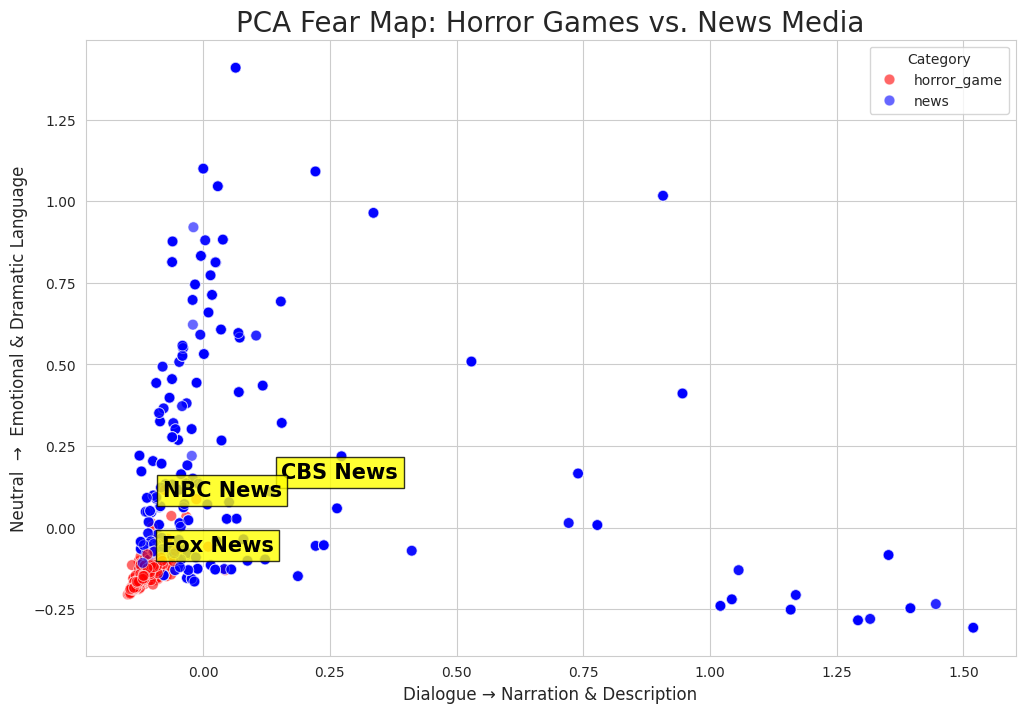

In [ ]:


plt.figure(figsize=(12,8))

# Sample points for speed
sample_df = df_all.sample(2000, random_state=42)

sns.scatterplot(
    x='pca_x', y='pca_y',
    hue='media_type',
    data=sample_df,
    alpha=0.6,
    s=60,
    palette={"horror_game": "red", "news": "blue"}

)

# Label the top news sources
for source, centroid in source_centroids.items():
    plt.text(
        centroid[0], centroid[1], source,
        fontsize=15, fontweight='bold', color='black',
        bbox=dict(facecolor='yellow', alpha=0.8, edgecolor='black')
    )


plt.title('PCA Fear Map: Horror Games vs. News Media', fontsize=20)
plt.xlabel('Dialogue → Narration & Description', fontsize=12)
plt.ylabel('Neutral  →  Emotional & Dramatic Language', fontsize=12)
plt.legend(title='Category')



# NRC Lexicon



Essentially, the Python verson of the NRC lexicon is very out of date with current python software and had consistent bugs when trying to loop the lexicon through df_all data and couldn't handle the text size of each segment (even though they were only 50 words). Instead, we manually downloaded the lexicon to our computer from github (https://github.com/aditeyabaral/lok-sabha-election-twitter-analysis/blob/master/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt) and split the file into the list of words and their delegated emotion according to NRCLex. Then a mask was created for just the fear words (emotion rating = 1). The fear percentage calculated what percent of the text consisted of the NRClex associated fear words.

During final revisions, the code was cleaned and re-executed, which resulted in slight variations in the generated graphs. In particular, the confusion matrix reflects a higher accuracy than previously observed. While the overall trends and conclusions remain consistent, a small number of visualizations may differ slightly from those presented on the poster.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving NRC-Emotion-Lexicon-Wordlevel-v0.92.txt to NRC-Emotion-Lexicon-Wordlevel-v0.92 (1).txt


In [ ]:
nrc = pd.read_csv(
    "NRC-Emotion-Lexicon-Wordlevel-v0.92.txt",
    sep="\t",
    names=["word","emotion","association"]
)

nrc = nrc[nrc["association"] == 1] # association 1 = fear in the lexicon

fear_words = set(
    nrc[nrc["emotion"] == "fear"]["word"]
)

list(fear_words)[:20]


['sectarian',
 'armored',
 'combatant',
 'anarchist',
 'dominate',
 'despair',
 'inmate',
 'criminal',
 'cult',
 'destructive',
 'omen',
 'howl',
 'desecration',
 'auditor',
 'rebel',
 'grieve',
 'trepidation',
 'smite',
 'startle',
 'hell']

Reading in the NRC lexicon and only selecting the words associated with fear. Each emotion association is given a number in the lexicon, fear is numbered 1. Then we add them all up and find the percentages considering the entire text.

In [ ]:
def fear_score_nrc(text):

    words = text.split()

    score = sum(1 for w in words if w in fear_words)

    return score

In [ ]:
df_all["word_count"] = df_all["clean_text"].str.split().apply(len)

df_all["fear_percentage"] = (
    df_all["fear_score"] / (df_all["word_count"] + 1)
) * 100

In [ ]:
df_all.groupby("media_type")["fear_percentage"].mean()

,fear_percentage
media_type,
horror_game,27.576648
news,11.980915


# (Visualization 3) NRC Fear Scoring with Lexicon Fear Words Percentage

We initially made a bar chart to represent the distribution of fear words in the documents using the NRC lexicon, but this graph revealed something very interesting. The graph shows that news media is technically "scarier" than horror games. After some further looking into df_all and reading both the game scripts directly and the news articles, we noticed that the news uses a lot more buzzwords that relate to fear in the NRCLex whereas video games rely a lot more on story context, world building, and anticipation to create the effect of horror. This did not show up when we made the TF-IDF vectorizor because the frequent usage of fear words was actually penalized in the vectorizor-- therefore we did not get to see the true "scariness" of the news.

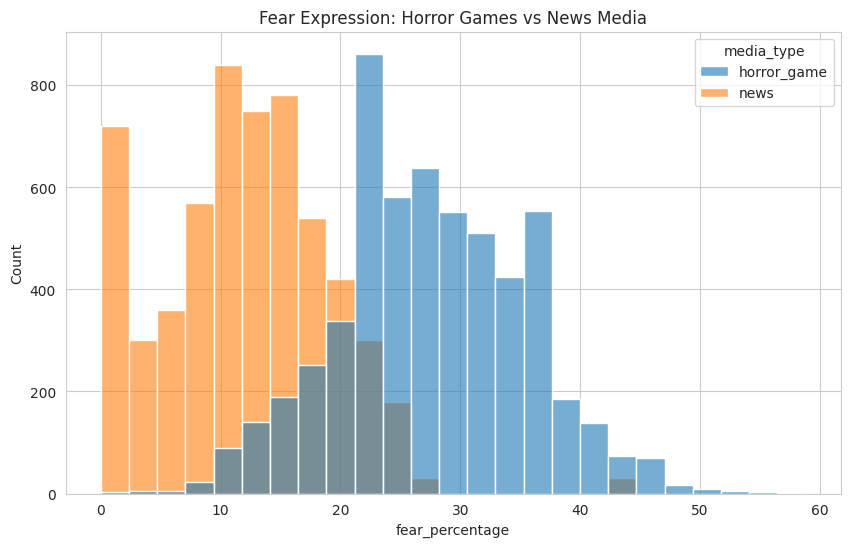

In [ ]:

plt.figure(figsize=(10,6))

sns.histplot(
    data=df_all,
    x="fear_percentage",
    hue="media_type",
    bins=25,
    alpha=0.6
)

plt.title("Fear Expression: Horror Games vs News Media")
plt.show()

# (Visualization 4) Word Cloud (Figure 5)

To add another fun way to visualize the data, we decided to add a word cloud of the most common words fetting picked up between the news articles and the video games. Unsuprisingly, President Trump was a pretty big one because he was likely mentioned in most in the of the news articles while the video games had more varied language.

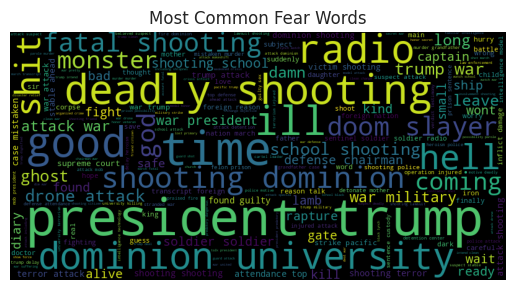

In [ ]:
from wordcloud import WordCloud

fear_words = nrc[nrc["association"] == 1]["word"].tolist()

fear_text = " ".join([
    word for word in df_all["clean_text"].str.split().explode()
    if word in fear_words
])

wc = WordCloud(width=800, height=400).generate(fear_text)

plt.imshow(wc)
plt.axis("off")
plt.title("Most Common Fear Words")

plt.show()

# (Visualization 5) NRCLex-Based Average Emotion Percentages (Figure 2.A)

To expand our research beyond just the fear category of the NRC Lexicon, we decided to compare the media types between all the the 8 categories of emotions in the database (anger, anticipation, disgust, fear, joy, sadness, surprise, and trust). We can see that video games are actually more spread out through each of the emotions, which makes sense because a good video game will have you experience a variety of emotions to make it overall more memorable and impactful. However, news stories are much shorter and pack stronger, negative emotions into smaller lines rather than space them out through a long story in order to keep engagement from readers.

In [ ]:
# Define the 8 primary emotions
emotions = ["anger", "anticipation", "disgust", "fear", "joy", "sadness", "surprise", "trust"]

# Create a dictionary for quick lookup from your NRC dataframe
# Assumes 'nrc' dataframe exists from your previous steps
emo_dict = {emo: set(nrc[(nrc["emotion"] == emo) & (nrc["association"] == 1)]["word"]) for emo in emotions}

# Function to calculate percentage for each emotion
def get_emotion_scores(text):
    words = str(text).split()
    word_count = len(words) + 1 # avoid division by zero
    scores = {}
    for emo in emotions:
        count = sum(1 for w in words if w in emo_dict[emo])
        scores[f"{emo}_percent"] = (count / word_count) * 100
    return pd.Series(scores)

# Apply to dataframe
emotion_df = df_all["clean_text"].apply(get_emotion_scores)
df_all = pd.concat([df_all, emotion_df], axis=1)

# Group by media_type for plotting
emotion_cols = [f"{emo}_percent" for emo in emotions]
summary = df_all.groupby("media_type")[emotion_cols].mean()

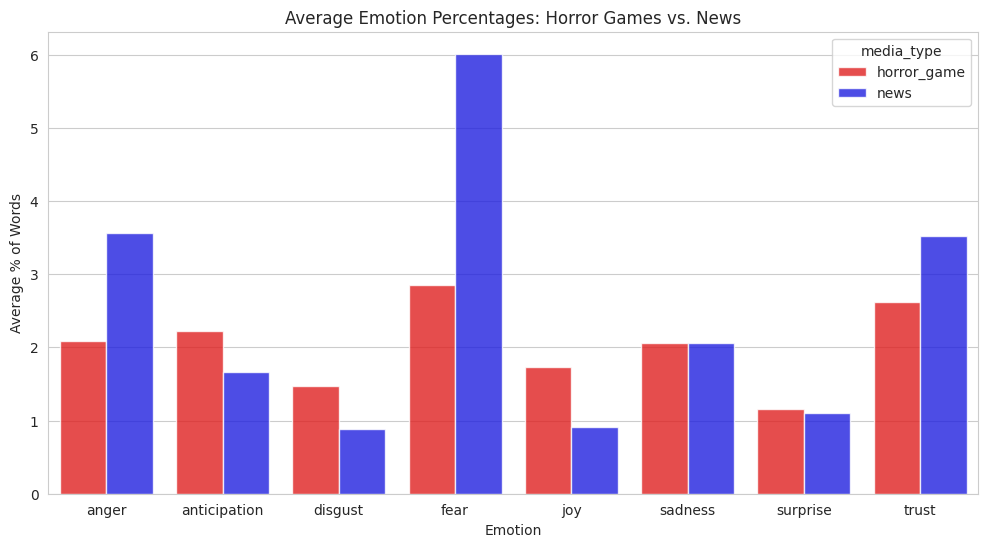

In [ ]:
melted_summary = summary.reset_index().melt(id_vars="media_type", var_name="Emotion", value_name="Percentage")
melted_summary["Emotion"] = melted_summary["Emotion"].str.replace("_percent", "")

plt.figure(figsize=(12, 6))
sns.barplot(data=melted_summary, x="Emotion", y="Percentage", hue="media_type", palette={"horror_game": "red", "news": "blue"}, alpha=0.8)
plt.title("Average Emotion Percentages: Horror Games vs. News")
plt.ylabel("Average % of Words")
plt.show()

# (Visualization 6) NRCLex-Based Average Emotion Percentages, Radar Graph (Figure 2.B)

To take this graph even further and make it more visually interesting, we made a radar plot as well, which is a little hard to understand it on its own so we paired it with the last visual on the final poster to make a more complete picture.

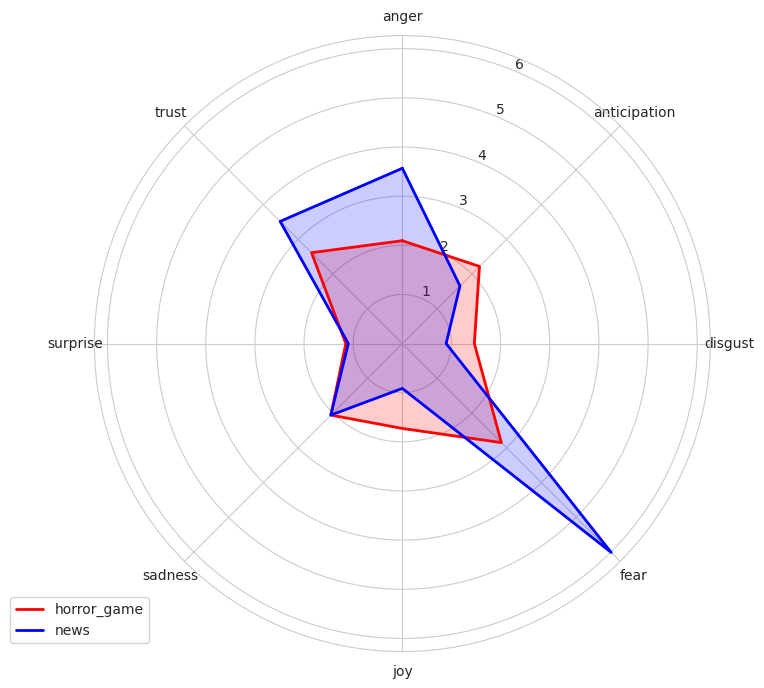

In [ ]:
from math import pi

def make_radar_chart(df_summary):
    categories = [c.replace("_percent", "") for c in emotion_cols]
    N = len(categories)

    # Repeat the first value to close the circle
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    colors = {"horror_game": "red", "news": "blue"}

    for media in df_summary.index:
        values = df_summary.loc[media].values.flatten().tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=media, color=colors[media])
        ax.fill(angles, values, color=colors[media], alpha=0.2)

    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    plt.xticks(angles[:-1], categories)
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    plt.show()

make_radar_chart(summary)

# MLM Comparison: Text-Based vs. Fear-Score-Based ⬇

# (Visualization 7) Fear Based Prediction (Figure 3)

Lastly to conclude our exploration of the data, we decided to make two small machine learning models with KNN Classifier to determine if the media type could be detected more efficiently with fear score or the text itself. To display the results, we created a colored confusion matrix map for both.

(note again*) During final revisions, the code was cleaned and re-executed, which resulted in slight variations in the generated graphs. In particular, the confusion matrix reflects a higher accuracy than previously observed. While the overall trends and conclusions remain consistent, a small number of visualizations may differ slightly from those presented on the poster.


Accuracy Score: 0.8956067855589387

Classification Report:
               precision    recall  f1-score   support

 horror_game       0.93      0.85      0.89      1162
        news       0.86      0.94      0.90      1137

    accuracy                           0.90      2299
   macro avg       0.90      0.90      0.90      2299
weighted avg       0.90      0.90      0.90      2299



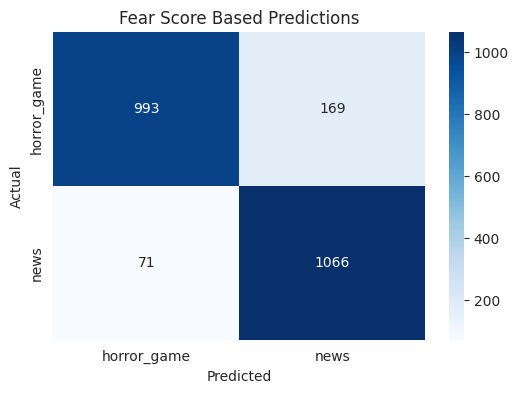

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Prepare the Data
# We use 'fear_percentage' as our feature (X) and 'media_type' as our target (y)
X = df_all[['fear_percentage']]
y = df_all['media_type']

# 2. Split the data into Training (80%) and Testing (20%) sets
# This lets us train the model on one group and test it on data it hasn't seen before
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 3. Cross-Validation (5-fold)
cv_scores = cross_val_score(knn, X, y, cv=5, scoring='accuracy')

print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())

# 4. Initialize the KNN Classifier
# K=5 is a common starting point; it looks at the 5 nearest data points
knn = KNeighborsClassifier(n_neighbors=5)

# 5. Train the model
knn.fit(X_train, y_train)

# 6. Make Predictions
y_pred = knn.predict(X_test)

# 7. Evaluate the Model
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 8. Visualize the Results with a Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
            xticklabels=knn.classes_, yticklabels=knn.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Fear Score Based Predictions')
plt.show()

# (Visualization 8) Text Based Prediction (Figure 3)

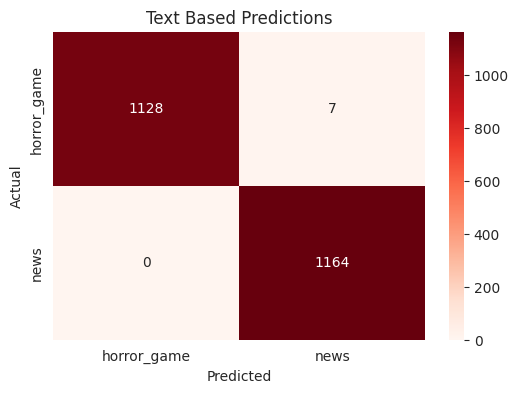

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(df_all['clean_text'])
y = df_all['media_type']

knn = KNeighborsClassifier(n_neighbors=5)
cv_scores = cross_val_score(knn, X_tfidf, y, cv=5, scoring='accuracy')

print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())

X_train, X_test, y_train, y_test = train_test_split(
    df_all['clean_text'], df_all['media_type'],
    test_size=0.2, random_state=26, stratify=df_all['media_type']
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

knn.fit(X_train_tfidf, y_train)

y_pred = knn.predict(X_test_tfidf)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Reds',
            xticklabels=knn.classes_, yticklabels=knn.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Text Based Predictions')
plt.show()